In [109]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
from math import factorial

# Part 1

In [110]:
# Parameters
rng = np.random.default_rng(30)
m = 10
A = 8
g = lambda i: A**i/factorial(i)


# Simulate
N = 10_000
X = np.empty(N, dtype=np.int64)
Y = np.empty_like(X)
X[0] = 0
for i in range(N-1):
    Y[i] = rng.integers(0,m+1)
    gY = g(Y[i])
    gX = g(X[i])

    if gY >= gX:
        X[i+1] = Y[i]
    else:
        accept = rng.choice([0,1], p=[1-gY/gX, gY/gX])
        if accept:
            X[i+1] = Y[i]
        else:
            X[i+1] = X[i]

$\chi^2$-test

In [111]:
burn_in = 1_000

# Expected 
p = np.array([g(i) for i in range(m+1)])
exp = (p / np.sum(p))

# Observed
obs = np.bincount(X[burn_in:], minlength=m+1)
obs = obs/np.sum(obs)

# Chisq-test
chi2_stat, p_value = ss.chisquare(obs, exp, ddof=0)
print(chi2_stat, p_value)

0.002591768717320412 1.0


<BarContainer object of 11 artists>

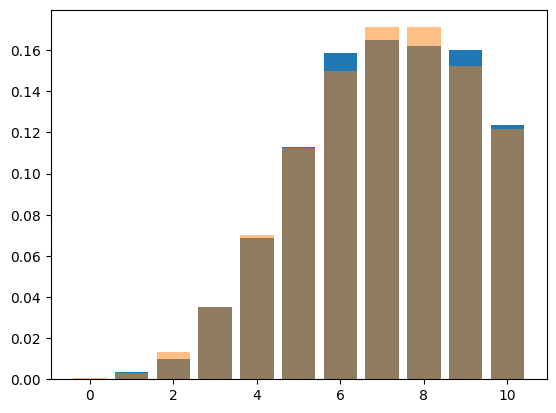

In [112]:
plt.bar(np.linspace(0,10,11),obs)
plt.bar(np.linspace(0,10,11),exp,alpha=0.5)

# Part 2

Use the Metropolis-Hastings algorithm directly to generate samples from the
distribution

In [113]:
rng = np.random.default_rng(30)

A1 = 4
A2 = 4
m = 10

def g(i, j):
    return (A1**i / factorial(i)) * (A2**j / factorial(j))

N = 10_000

IJ = np.zeros((N, 2), dtype=int)

# initial valid state
IJ[0] = (0, 0)

for t in range(N - 1):

    i, j = IJ[t]

    # propose new state
    while True:
        i_new = rng.integers(0, m + 1)
        j_new = rng.integers(0, m + 1)
        if i_new + j_new <= m:
            break

    # MH acceptance ratio
    g_new = g(i_new, j_new)
    g_old = g(i, j)

    alpha = min(1.0, g_new / g_old)

    if rng.random() < alpha:
        IJ[t + 1] = (i_new, j_new)
    else:
        IJ[t + 1] = (i, j)

0.017267488096493096 1.0


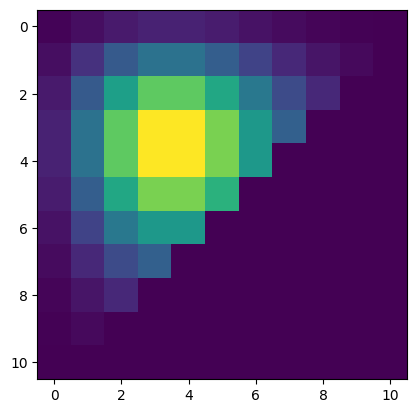

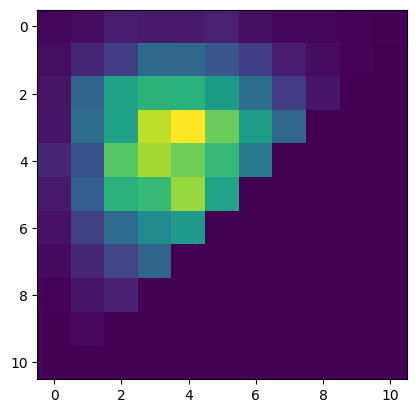

In [114]:
burn_in = 1_000

# Expected 
p = np.empty((m+1,m+1))
for ii in range(m+1):
    for jj in range(m+1):
        if ii+jj > m:
            p[ii,jj] = 0
        else:
            p[ii,jj] = g(ii,jj)

exp = p / np.sum(p)

# Observed
obs = np.zeros((m+1,m+1))
for (i,j) in IJ:
    obs[i,j] += 1
obs = obs / np.sum(obs)

# Chisq-test
chi2_stat, p_value = ss.chisquare(obs[np.nonzero(obs)], exp[np.nonzero(exp)], ddof=0)
print(chi2_stat, p_value)

plt.imshow(p)
plt.show()
plt.imshow(obs)
plt.show()

### Use coordinatewise Metropolis-Hastings to generate samples from the distribution.

In [115]:
rng = np.random.default_rng(30)

A1 = 4
A2 = 4
m = 10

def g(i, j):
    return (A1**i / factorial(i)) * (A2**j / factorial(j))

N = 10_000

IJ = np.zeros((N, 2), dtype=int)

# init
IJ[0] = (0, 0)

for t in range(N - 1):

    i, j = IJ[t]

    # Step 1: update i | j
    i_new = rng.integers(0, m - j + 1)

    g_new = g(i_new, j)
    g_old = g(i, j)

    alpha = min(1.0, g_new / g_old)

    if rng.random() < alpha:
        i = i_new

    # Step 2: update j | i
    j_new = rng.integers(0, m - i + 1)

    g_new = g(i, j_new)
    g_old = g(i, j)

    alpha = min(1.0, g_new / g_old)

    if rng.random() < alpha:
        j = j_new

    IJ[t + 1] = (i, j)

0.003438011895978261 1.0


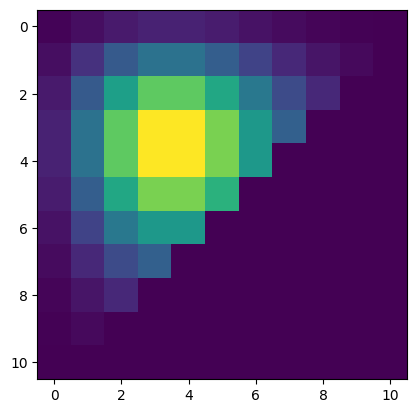

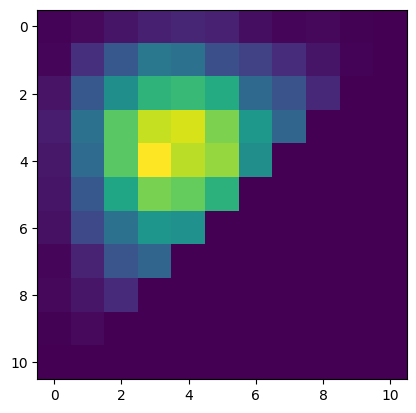

In [116]:
burn_in = 1_000

# Expected 
p = np.empty((m+1,m+1))
for ii in range(m+1):
    for jj in range(m+1):
        if ii+jj > m:
            p[ii,jj] = 0
        else:
            p[ii,jj] = g(ii,jj)

exp = p / np.sum(p)

# Observed
obs = np.zeros((m+1,m+1))
for (i,j) in IJ:
    obs[i,j] += 1
obs = obs / np.sum(obs)

# Chisq-test
chi2_stat, p_value = ss.chisquare((obs+0.01).flatten(), (exp+0.01).flatten(), ddof=0)
print(chi2_stat, p_value)

plt.imshow(p)
plt.show()
plt.imshow(obs)
plt.show()

### Use Gibbs sampling to generate samples from the distribution

In [117]:
rng = np.random.default_rng(30)

A1 = 4
A2 = 4
m = 10

def g(i, j):
    return (A1**i / factorial(i)) * (A2**j / factorial(j))

N = 10_000

IJ = np.zeros((N, 2), dtype=int)

# init
IJ[0] = (0, 0)

# Calculate conditional propabilities
cond_prop_j = np.zeros((m+1,m+1))
for j in range(m+1):
    props = np.array([(A1**i / factorial(i)) for i in range(m-j+1)])
    cond_prop_j[j,:m-j+1] = props / props.sum()

cond_prop_i = np.zeros((m+1,m+1))
for i in range(m+1):
    props = np.array([(A2**j / factorial(j)) for j in range(m-i+1)])
    cn = 1/np.sum(props)
    cond_prop_i[i,:m-i+1] = props / props.sum()

## these are the same because A1=A2

for t in range(N - 1):

    i, j = IJ[t]

    # sample
    i_new = rng.choice(m+1, p=cond_prop_i[j])
    j_new = rng.choice(m+1, p=cond_prop_j[i_new])

    # update
    IJ[t + 1] = (i_new, j_new)

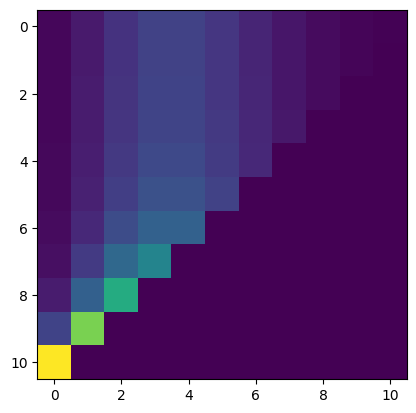

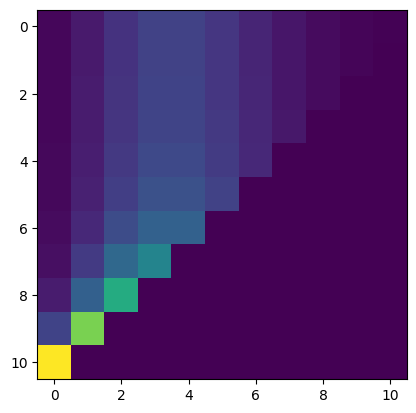

In [118]:
plt.imshow(cond_prop_j)
plt.show()
plt.imshow(cond_prop_i)

0.002468765158553726 1.0


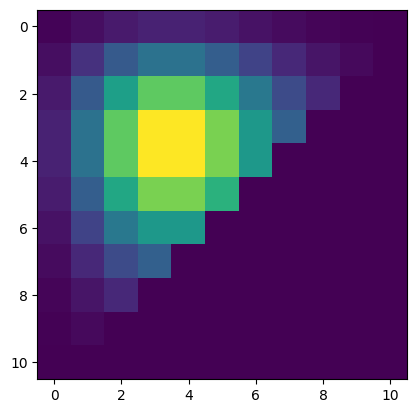

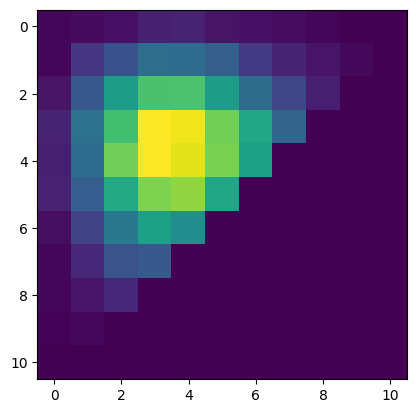

In [119]:
burn_in = 1_000

# Expected 
p = np.empty((m+1,m+1))
for ii in range(m+1):
    for jj in range(m+1):
        if ii+jj > m:
            p[ii,jj] = 0
        else:
            p[ii,jj] = g(ii,jj)

exp = p / np.sum(p)

# Observed
obs = np.zeros((m+1,m+1))
for (i,j) in IJ:
    obs[i,j] += 1
obs = obs / np.sum(obs)

# Chisq-test
chi2_stat, p_value = ss.chisquare((obs+0.01).flatten(), (exp+0.01).flatten(), ddof=0)
print(chi2_stat, p_value)

plt.imshow(p)
plt.show()
plt.imshow(obs)
plt.show()

# Part 3

### a)

In [120]:
rng = np.random.default_rng(30)

# Parameters
mean = [0, 0]
rho = 0.5
cov = [[1,   rho],
        [rho, 1  ]]

# Sample
xi_gamma = rng.multivariate_normal(mean, cov, size=1)

xi = xi_gamma[:, 0]
gamma = xi_gamma[:, 1]

# Transform
theta = np.exp(xi)
psi = np.exp(gamma)

In [128]:
theta,psi

(array([0.1763436]), array([0.37082036]))

### b)

In [121]:
rng = np.random.default_rng(30)

n = 10
X = rng.normal(loc=theta,
                     scale=np.sqrt(psi),
                     size=n)

print("X =", X)

X = [ 1.13522166  0.62896617 -0.4142704   0.04724344  0.00173935  1.6149391
 -0.39803376  1.01413417  0.25135404  0.79860169]


### c)

In [122]:
# Parameters
n = len(X)
xbar = np.mean(X)
s2 = np.var(X, ddof=1)
rho = 0.5

def log_post(theta, psi, x, rho=0.5):

    n = len(x)
    xbar = np.mean(x)
    s2 = np.var(x, ddof=1)

    log_prior = (
        -np.log(theta)
        -np.log(psi)
        -(np.log(theta)**2
          -2*rho*np.log(theta)*np.log(psi)
          +np.log(psi)**2)
        /(2*(1-rho**2))
    )

    log_like = (
        -(n/2)*np.log(psi)
        -((n-1)*s2 + n*(xbar-theta)**2)/(2*psi)
    )

    return log_like + log_prior

In [123]:
def metropolis_hastings(x,
                        n_iter=50000,
                        burn=5000,
                        proposal_sd=0.2):
    rng = np.random.default_rng(30)

    samples = np.zeros((n_iter, 2))

    xi = 0.0
    gamma = 0.0

    accepted = 0

    for t in range(n_iter):

        xi_prop = xi + rng.normal(0, proposal_sd)
        gamma_prop = gamma + rng.normal(0, proposal_sd)

        theta_curr = np.exp(xi)
        psi_curr = np.exp(gamma)

        theta_prop = np.exp(xi_prop)
        psi_prop = np.exp(gamma_prop)

        log_alpha = (
            log_post(theta_prop, psi_prop, x)
            - log_post(theta_curr, psi_curr, x)
        )

        if np.log(rng.uniform()) < log_alpha:
            xi = xi_prop
            gamma = gamma_prop
            accepted += 1

        samples[t] = [np.exp(xi), np.exp(gamma)]

    print("Acceptance rate:",
          accepted / n_iter)

    return samples[burn:]

Acceptance rate: 0.76852


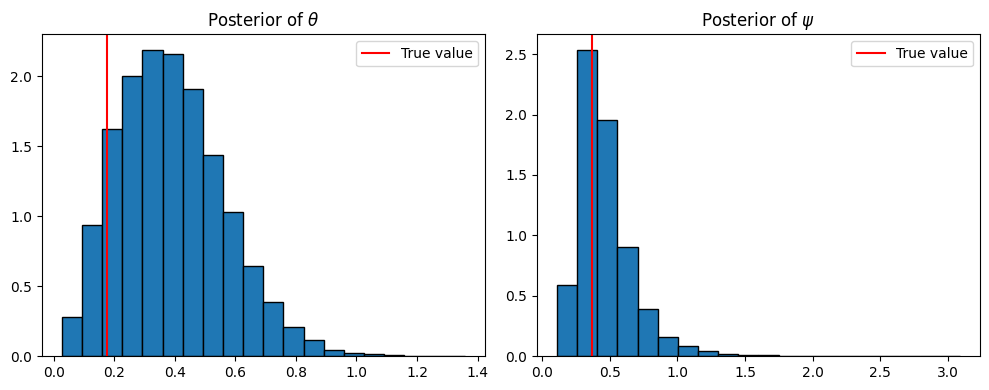

In [170]:
rng = np.random.default_rng(30)

n = 10
X = rng.normal(loc=theta,
                     scale=np.sqrt(psi),
                     size=n)

samples10 = metropolis_hastings(X)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# θ posterior
axes[0].hist(samples10[:, 0], bins=20, density=True, edgecolor="black")
axes[0].axvline(theta, color="red", label="True value")
axes[0].set_title(r"Posterior of $\theta$")

axes[0].legend()

# ψ posterior
axes[1].hist(samples10[:, 1], bins=20, density=True, edgecolor="black")
axes[1].axvline(psi, color="red", label="True value")
axes[1].set_title(r"Posterior of $\psi$")

axes[1].legend()

plt.tight_layout()
plt.show()

Acceptance rate: 0.52294


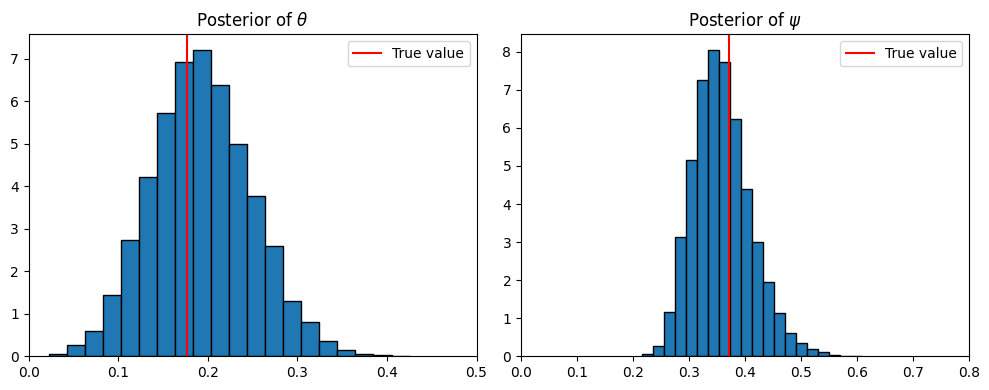

In [167]:
rng = np.random.default_rng(30)

n = 100
X = rng.normal(loc=theta,
                     scale=np.sqrt(psi),
                     size=n)

samples100 = metropolis_hastings(X)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# θ posterior
axes[0].hist(samples100[:, 0], bins=20, density=True, edgecolor="black")
axes[0].axvline(theta, color="red", label="True value")
axes[0].set_title(r"Posterior of $\theta$")
axes[0].set_xlim(0, 0.5)
axes[0].legend()

# ψ posterior
axes[1].hist(samples100[:, 1], bins=20, density=True, edgecolor="black")
axes[1].axvline(psi, color="red", label="True value")
axes[1].set_title(r"Posterior of $\psi$")
axes[1].set_xlim(0, 0.8)
axes[1].legend()

plt.tight_layout()
plt.show()

Acceptance rate: 0.15974


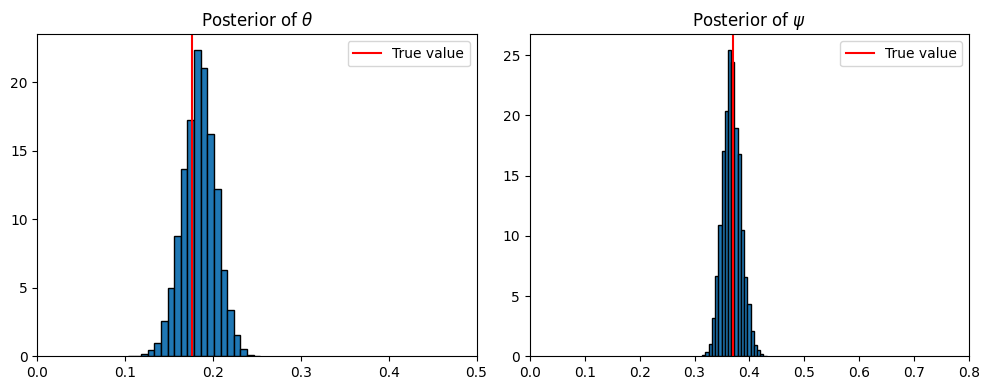

In [166]:
rng = np.random.default_rng(30)

n = 1000
X = rng.normal(loc=theta,
                     scale=np.sqrt(psi),
                     size=n)

samples1000 = metropolis_hastings(X)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# θ posterior
axes[0].hist(samples1000[:, 0], bins=20, density=True, edgecolor="black")
axes[0].axvline(theta, color="red", label="True value")
axes[0].set_title(r"Posterior of $\theta$")
axes[0].set_xlim(0, 0.5)
axes[0].legend()

# ψ posterior
axes[1].hist(samples1000[:, 1], bins=20, density=True, edgecolor="black")
axes[1].axvline(psi, color="red", label="True value")
axes[1].set_title(r"Posterior of $\psi$")
axes[1].set_xlim(0, 0.8)
axes[1].legend()

plt.tight_layout()
plt.show()